# Soutenance
Groupe B

In [31]:
import os
import numpy as np
import json
import matplotlib.pyplot as plt
import pathlib
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array, array_to_img
from tensorflow.keras import layers, models
import imageio
from PIL import Image

print("TensorFlow:", tf.__version__)
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU détecté — memory growth activé")
else:
    print("Aucun GPU détecté — inférence sur CPU")

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ------------------------------------
# Config
# ------------------------------------
DATASET_DIR = "./dataset"

CLASSIFIER_PATH = "liv1-classification.keras"
CLASSIFIER_SIZE = (224, 224)
CLASS_NAMES = ['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']

DENOISER_PATH = "liv2-denoising.h5"
DENOISER_SIZE = (224, 224)

CAPTION_MODEL_PATH = "liv3-captionning.keras"
CAPTION_SIZE = (299, 299)

CAPTION_TOKENIZER  = "tokenizer.json"
CAPTION_I2W  = "index2word.json"

print("→ tok :", CAPTION_TOKENIZER)
print("→ i2w :", CAPTION_I2W)


TensorFlow: 2.20.0
Aucun GPU détecté — inférence sur CPU
→ tok : tokenizer.json
→ i2w : index2word.json


In [32]:
# Load models
classifier = load_model(CLASSIFIER_PATH)

def build_denoiser(input_shape=(224, 224, 3)):
    inputs = layers.Input(shape=input_shape)
    c1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D((2,2), padding='same')(c1)
    c2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D((2,2), padding='same')(c2)
    c3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(p2)
    u1 = layers.UpSampling2D((2,2))(c3)
    concat1 = layers.Concatenate()([u1, c2])
    c4 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(concat1)
    u2 = layers.UpSampling2D((2,2))(c4)
    concat2 = layers.Concatenate()([u2, c1])
    c5 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(concat2)
    outputs = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(c5)
    model = models.Model(inputs, outputs)
    return model

denoiser = build_denoiser()
denoiser.load_weights(DENOISER_PATH)

In [33]:
def load_images(folder, target_size=(224, 224)):  # changer de 128 à 224
    images = []
    paths = []
    for fname in os.listdir(folder):
        path = os.path.join(folder, fname)
        if not os.path.isfile(path):
            continue
        try:
            img = load_img(path, target_size=target_size)
            arr = img_to_array(img) / 255.0
            images.append(arr)
            paths.append(path)
        except Exception as e:
            print(f'Skipped {fname}: {e}')
    return np.array(images), paths

X, paths = load_images(DATASET_DIR, target_size=(224,224))
print(f'Loaded {len(X)} images from {DATASET_DIR}.')

Loaded 200 images from ./dataset.


In [34]:
# Classify and filter photos only
preds = classifier.predict(X)

if isinstance(preds, list):
    for i, p in enumerate(preds):
        print(f"Output {i}: shape={p.shape}")

class_preds = preds[0] if isinstance(preds, list) else preds

photo_mask = (class_preds.flatten() > 0.5)

X_photos = X[photo_mask]
photo_paths = [p for i, p in enumerate(paths) if photo_mask[i]]

print(f'Detected {len(X_photos)} photos out of {len(X)} total images.')

for i, path in enumerate(photo_paths, 1):
    print(f'{i} - Photo: {path}')
    detected_dir = "./detected_photos"
    os.makedirs(detected_dir, exist_ok=True)
    img_uint8 = (X_photos[i-1] * 255).astype(np.uint8)
    imageio.imsave(os.path.join(detected_dir, os.path.basename(path)), img_uint8)


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 350ms/step
Output 0: shape=(200, 1)
Output 1: shape=(200, 5)
Detected 110 photos out of 200 total images.
1 - Photo: ./dataset/photo_0011.jpg
2 - Photo: ./dataset/painting_00046.jpg
3 - Photo: ./dataset/photo_0002.jpg
4 - Photo: ./dataset/painting_00032.jpg
5 - Photo: ./dataset/photo_0071.jpg
6 - Photo: ./dataset/photo_0047.jpg
7 - Photo: ./dataset/photo_0093.jpg
8 - Photo: ./dataset/painting_00023.jpg
9 - Photo: ./dataset/painting_00011.jpg
10 - Photo: ./dataset/painting_00044.jpg
11 - Photo: ./dataset/painting_00009.jpg
12 - Photo: ./dataset/photo_0074.jpg
13 - Photo: ./dataset/photo_0060.jpg
14 - Photo: ./dataset/photo_0092.jpg
15 - Photo: ./dataset/photo_0057.jpg
16 - Photo: ./dataset/photo_0005.jpg
17 - Photo: ./dataset/photo_0039.jpg
18 - Photo: ./dataset/painting_00048.jpg
19 - Photo: ./dataset/photo_0076.jpg
20 - Photo: ./dataset/painting_00022.jpg
21 - Photo: ./dataset/photo_0062.jpg
22 - Photo: ./dataset/painting_00003.jpg
23 - Photo: ./dataset/sch

In [35]:
# Add noise only to detected photos
def add_noise(images, noise_factor=0.2):
    noisy = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy = np.clip(noisy, 0., 1.)
    return noisy

X_noisy = add_noise(X_photos)

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step


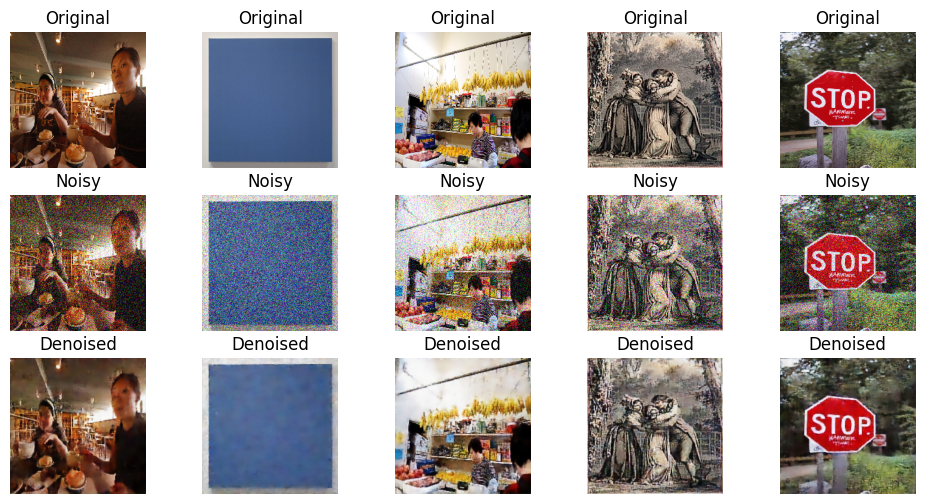

In [36]:
# Denoise only the photo images
X_denoised = denoiser.predict(X_noisy)

# Show original, noisy, and denoised
n = min(5, len(X_denoised))
plt.figure(figsize=(12, 6))
for i in range(n):
    plt.subplot(3, n, i+1)
    plt.imshow(X_photos[i])
    plt.axis('off')
    plt.title('Original')

    plt.subplot(3, n, i+1+n)
    plt.imshow(X_noisy[i])
    plt.axis('off')
    plt.title('Noisy')

    plt.subplot(3, n, i+1+2*n)
    plt.imshow(X_denoised[i])
    plt.axis('off')
    plt.title('Denoised')
plt.show()

In [37]:
# Save only denoised photos
DENOISED_OUTPUT_DIR = './denoised_results'
os.makedirs(DENOISED_OUTPUT_DIR, exist_ok=True)

for img_arr, path in zip(X_denoised, photo_paths):
    name = os.path.basename(path)
    out_path = os.path.join(DENOISED_OUTPUT_DIR, name)
    array_to_img(img_arr).save(out_path)

print('Denoised photo images saved in', DENOISED_OUTPUT_DIR)

Denoised photo images saved in ./denoised_results


In [38]:
def _tokenizer_from_json_file(path):
    try:
        from tensorflow.keras.preprocessing.text import tokenizer_from_json
    except Exception:
        from keras.preprocessing.text import tokenizer_from_json
    with open(path, "r", encoding="utf-8") as f:
        return tokenizer_from_json(f.read())

tok = None
index2word = {}
if os.path.isfile(CAPTION_TOKENIZER):
    tok = _tokenizer_from_json_file(CAPTION_TOKENIZER)
    print(f"{CAPTION_TOKENIZER} chargé (vocab ≈)", len(tok.word_index))
else:
    print(f"{CAPTION_TOKENIZER} introuvable — certaines fonctions seront limitées.")

if os.path.isfile(CAPTION_I2W):
    with open(CAPTION_I2W, "r", encoding="utf-8") as f:
        index2word = json.load(f)
    index2word = {int(k): v for k, v in index2word.items()}
else:
    if tok is not None:
        index2word = {i: w for w, i in tok.word_index.items()}
        index2word[0] = "<pad>"
    print("index2word.json introuvable — reconstruction simplifiée si possible.")

START_TOKEN = "<start>"
END_TOKEN   = "<end>"
OOV_TOKEN   = "<unk>"

def get_start_end_ids():
    if tok is None:
        return 1, None
    sid = tok.word_index.get(START_TOKEN, 1)
    eid = tok.word_index.get(END_TOKEN, None)
    return sid, eid

tokenizer.json chargé (vocab ≈) 4625


In [39]:
decoder = keras.models.load_model(CAPTION_MODEL_PATH, compile=False)
inp = decoder.inputs[0]
need_feats = False
try:
    shp = tuple(inp.shape)
    if len(shp) == 2 and (shp[-1] is None or int(shp[-1]) == 2048):
        need_feats = True
    elif len(shp) == 4:
        need_feats = False
except Exception:
    need_feats = ('img_feat' in (inp.name or ''))

seq_len = None
try:
    seq_in = decoder.inputs[1]
    seq_len = int(seq_in.shape[-1])
except Exception:
    for t in decoder.inputs:
        if getattr(t, 'name', '').startswith('seq_in'):
            try: seq_len = int(t.shape[-1])
            except Exception: pass
            break

def get_model_seq_len(model):
    try:
        t = model.inputs[1]
        s = t.shape[-1]
        return int(s) if s is not None else 19
    except Exception:
        return 19

MAX_LEN_MODEL = (seq_len + 1) if (seq_len is not None) else (get_model_seq_len(decoder) + 1)

print("Modèle chargé. Entrée attendue:", "features 2048" if need_feats else "image brute")
print("Longueur de séquence attendue (MAX_LEN):", MAX_LEN_MODEL)

image_encoder = None
if need_feats:
    base_cnn = keras.applications.InceptionV3(include_top=False, weights='imagenet', input_shape=CAPTION_SIZE + (3,))
    x = keras.layers.GlobalAveragePooling2D()(base_cnn.output)
    image_encoder = keras.Model(base_cnn.input, x, name="inceptionv3_encoder")
    print("Encodeur InceptionV3 prêt (features 2048)")

Modèle chargé. Entrée attendue: image brute
Longueur de séquence attendue (MAX_LEN): 20


In [40]:
def preprocess_img(path):
    img = Image.open(path).convert("RGB").resize(CAPTION_SIZE)
    arr = np.array(img).astype(np.float32)
    return keras.applications.inception_v3.preprocess_input(arr)

def decode_tokens(ids):
    words = []
    for i in ids:
        if i == 0:
            continue
        w = index2word.get(i, OOV_TOKEN)
        if w in (START_TOKEN, END_TOKEN):
            continue
        words.append(w)
    return " ".join(words)

In [41]:
def generate_caption(img_path, max_len=None):
    if max_len is None:
        if 'MAX_LEN_MODEL' in globals():
            max_len = int(MAX_LEN_MODEL)
        else:
            try:
                s = decoder.inputs[1].shape[-1]
                max_len = (int(s) + 1) if s is not None else 25
            except Exception:
                max_len = 25
    sid, eid = get_start_end_ids()
    seq = [sid]
    if need_feats:
        arr = preprocess_img(img_path)[np.newaxis, ...]
        feat = image_encoder.predict(arr, verbose=0).astype(np.float32)
        img_input = feat[0]
    else:
        img_input = preprocess_img(img_path)
    for _ in range(max_len-1):
        inp_seq = keras.preprocessing.sequence.pad_sequences([seq], maxlen=max_len-1, padding='post')
        if need_feats:
            preds = decoder.predict([img_input[np.newaxis, ...], inp_seq], verbose=0)
        else:
            preds = decoder.predict([img_input[np.newaxis, ...], inp_seq], verbose=0)
        last_pos = min(len(seq)-1, max_len-2)
        prob = preds[0, last_pos]
        next_id = int(np.argmax(prob))
        if (eid is not None and next_id == eid) or next_id == 0:
            break
        seq.append(next_id)
    return decode_tokens(seq)

Image: ./denoised_results/photo_0011.jpg | MAX_LEN utilisé: 20


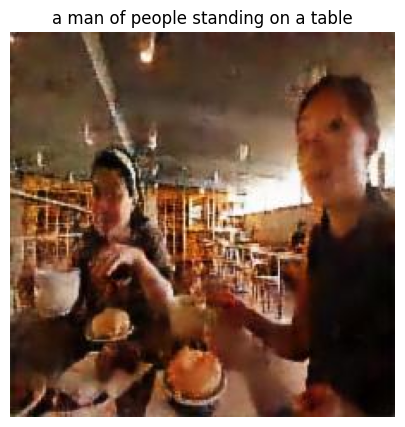

Caption: a man of people standing on a table
Image: ./denoised_results/painting_00046.jpg | MAX_LEN utilisé: 20


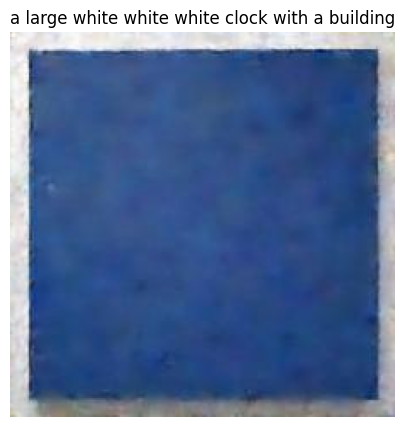

Caption: a large white white white clock with a building
Image: ./denoised_results/photo_0002.jpg | MAX_LEN utilisé: 20


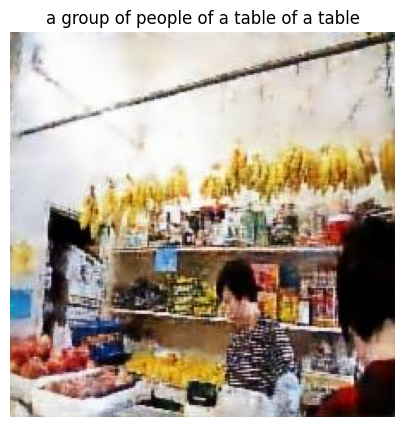

Caption: a group of people of a table of a table
Image: ./denoised_results/painting_00032.jpg | MAX_LEN utilisé: 20


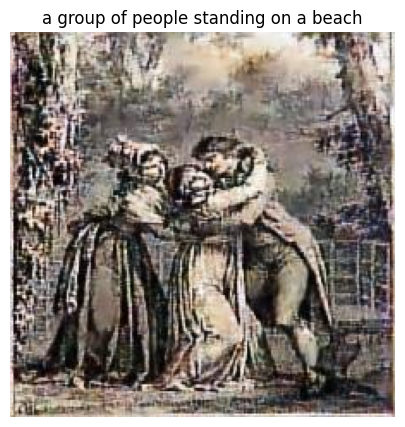

Caption: a group of people standing on a beach
Image: ./denoised_results/photo_0071.jpg | MAX_LEN utilisé: 20


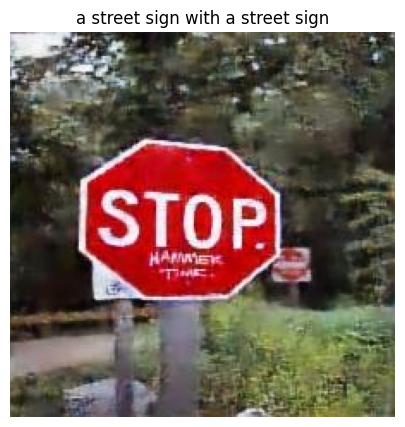

Caption: a street sign with a street sign
Image: ./denoised_results/photo_0047.jpg | MAX_LEN utilisé: 20


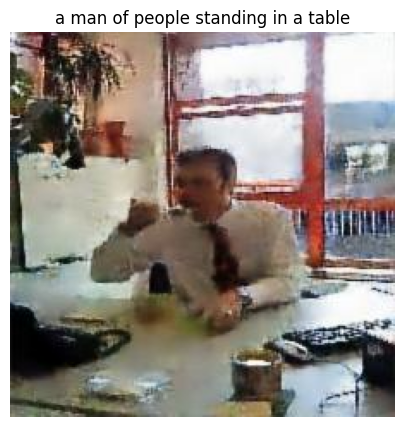

Caption: a man of people standing in a table
Image: ./denoised_results/photo_0093.jpg | MAX_LEN utilisé: 20


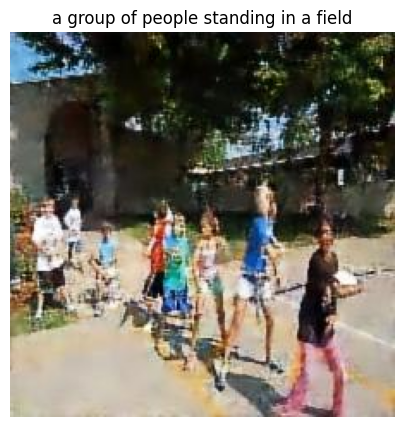

Caption: a group of people standing in a field
Image: ./denoised_results/painting_00023.jpg | MAX_LEN utilisé: 20


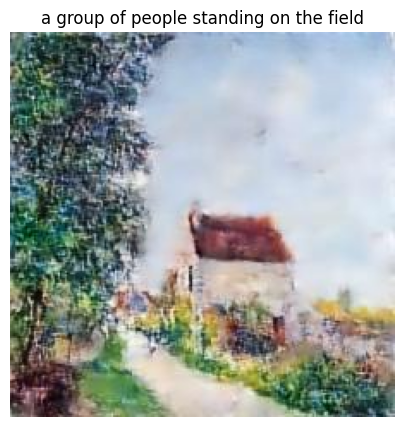

Caption: a group of people standing on the field
Image: ./denoised_results/painting_00011.jpg | MAX_LEN utilisé: 20


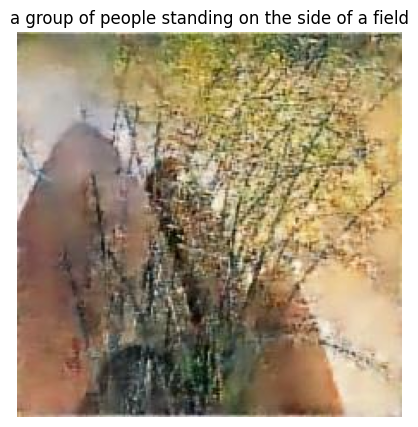

Caption: a group of people standing on the side of a field
Image: ./denoised_results/painting_00044.jpg | MAX_LEN utilisé: 20


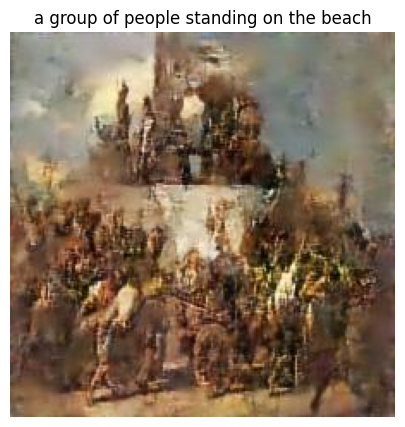

Caption: a group of people standing on the beach
Image: ./denoised_results/painting_00009.jpg | MAX_LEN utilisé: 20


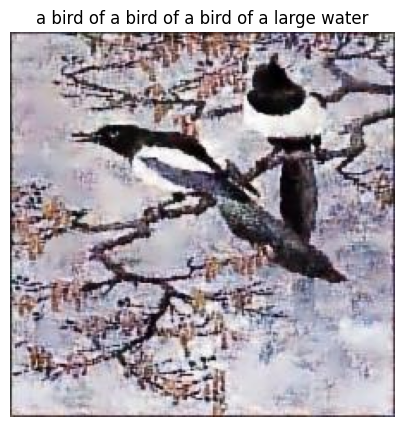

Caption: a bird of a bird of a bird of a large water
Image: ./denoised_results/photo_0074.jpg | MAX_LEN utilisé: 20


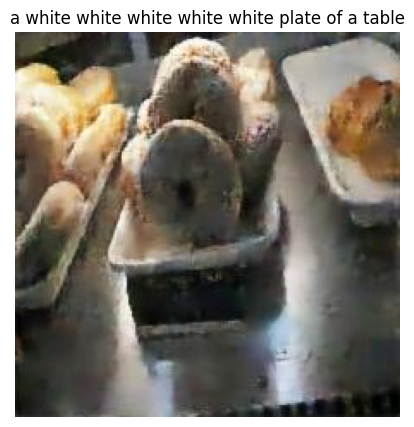

Caption: a white white white white white plate of a table
Image: ./denoised_results/photo_0060.jpg | MAX_LEN utilisé: 20


In [ ]:
search_dir = DENOISED_OUTPUT_DIR if os.path.isdir(DENOISED_OUTPUT_DIR) else DATASET_DIR
cand = [f for f in (os.listdir(search_dir) if os.path.isdir(search_dir) else []) if f.lower().endswith(('.jpg','.jpeg','.png'))]
if cand:
    for fname in cand:
        img_path = os.path.join(search_dir, fname)
        print("Image:", img_path, "| MAX_LEN utilisé:", int(MAX_LEN_MODEL) if 'MAX_LEN_MODEL' in globals() else 'inconnu')
        cap = generate_caption(img_path)
        plt.figure(figsize=(6,5))
        plt.imshow(Image.open(img_path)); plt.axis('off')
        plt.title(cap)
        plt.show()
        print("Caption:", cap)
else:
    print("Aucune image trouvée dans", search_dir)